In [48]:
import pytensor
# Tell PyTensor to use a more robust (but slower) backend that avoids C compilation issues.
# Place this in the first cell of your notebook.
pytensor.config.optimizer = 'fast_compile'

import pandas as pd
import numpy as np
import pymc as pm
import scipy.stats as stats
import arviz as az

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

import joblib



## Get player details


In [332]:
players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)
fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_24_25.csv')

players_preds = players_preds.rename(columns={'FPL_Name': 'fpl_name', 'Understat_Name': 'understat_name'})
# Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')
players_preds.dropna(subset=['FPL_ID'], inplace=True)

players_preds = players_preds.drop(['event', 'understat_name', 'fpl_name', 'FPL_ID','FPL_Name', 'team', 'xG_preds', 'xA_preds', 'cs_preds', 'y_preds', 'saves_preds', 'xgc_preds', 'h_team', 'a_team','was_home', 'assists_x'], axis=1)
player_cols = players_preds.columns.tolist()

In [333]:
data_cols_all = ['clean_sheets',  'creativity', 'ict_index',  'influence',  'selected',  'threat',  'transfers_balance', 'transfers_in',  'transfers_out',  'value',
                 'team_h_difficulty',  'team_a_difficulty', 'ownership_change',  'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

            'clean_sheets_1',  'expected_assists_1',  'expected_goal_involvements_1',
            'expected_goals_1',  'expected_goals_conceded_1',  'goals_conceded_1',  'goals_scored_1',  'ict_index_1',  'influence_1',
            'creativity_1',  'threat_1',  'minutes_1',  'own_goals_1',  'penalties_missed_1',  'penalties_saved_1',  'red_cards_1',
            'yellow_cards_1',  'saves_1',  'starts_1',  'team_a_score_1',  'team_h_score_1',  'total_points_1',  'goals_1',  'shots_1',
            'xG_1',  'xA_1',  'assists_x_1',  'key_passes_1',  'npg_1',  'npxG_1',  'xGChain_1',  'xGBuildup_1',  'xP_1',

            'clean_sheets_3',  'expected_assists_3',  'expected_goal_involvements_3',  'expected_goals_3',  'expected_goals_conceded_3',
            'goals_conceded_3',  'goals_scored_3',  'ict_index_3',  'influence_3',  'creativity_3',  'threat_3',  'minutes_3',  'own_goals_3',
            'penalties_missed_3',  'penalties_saved_3',  'red_cards_3',  'yellow_cards_3',  'saves_3',  'starts_3',  'team_a_score_3',
            'team_h_score_3',  'total_points_3',  'goals_3',  'shots_3',  'xG_3',  'xA_3',  'assists_x_3', 'key_passes_3',
            'npg_3',  'npxG_3',  'xGChain_3',  'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_assists_5',  'expected_goal_involvements_5',  'expected_goals_5',  'expected_goals_conceded_5',  'goals_conceded_5',
            'goals_scored_5',  'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',  'penalties_missed_5',  'penalties_saved_5',
            'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5',  'total_points_5',  'goals_5',  'shots_5',  'xG_5',  'xA_5',
            'assists_x_5', 'key_passes_5',  'npg_5',  'npxG_5',  'xGChain_5',  'xGBuildup_5',  'xP_5', 'xP_cost'
        ]

data_cols_gk = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

                'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1',
                'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'goals_1', 'xG_1',
                'key_passes_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3',
                'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'key_passes_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_goals_conceded_5',  'goals_conceded_5', 'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',
                'penalties_saved_5', 'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5', 'total_points_5',  'goals_5',  'shots_5',
                'key_passes_5', 'xGChain_5',  'xGBuildup_5', 'xP_5', 'xP_cost'
                ]

data_cols = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty',  'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'xP', 'ownership_percent',

                'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1',
                'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
                'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1',
                'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3',
                'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
                'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5',
                'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
                'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5',
                'xGChain_5', 'xGBuildup_5', 'xP_5', 'xP_cost'
        ]

feats_cols = ["selected", "transfers_in", "transfers_out", "value", "xP_5", "total_points_1", "team_h_difficulty", "team_a_difficulty", "ownership_percent"]

feats_cols_gk = [
                'ownership_percent', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty', 'team_a_difficulty',
                 'total_points_1', 'minutes_5', 'expected_goals_conceded_5', 'saves_5',
                ]

feats_cols_def = [
                'ownership_percent', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty', 'team_a_difficulty',
                 'total_points_1', 'minutes_5', 'expected_goals_conceded_5', 'xG_5', 'xA_5'
                ]

feats_cols_mid = [
                'ownership_percent', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty', 'team_a_difficulty',
                 'total_points_1', 'minutes_5','npxG_5',
                ]

feats_cols_fwd = [
                'ownership_percent', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty', 'team_a_difficulty',
                 'total_points_1', 'minutes_5','npxG_5',
                ]

FPL_teams_23_24 = ['West Ham United', 'Manchester United', 'Everton', 'Bournemouth',
       'Brighton and Hove Albion', 'Crystal Palace', 'Fulham', 'Luton',
       'Tottenham Hotspur', 'Newcastle United', 'Aston Villa',
       'Liverpool', 'Chelsea', 'Sheffield United', 'Nottingham Forest',
       'Burnley', 'Arsenal', 'Manchester City', 'Wolverhampton Wanderers',
       'Brentford']

In [334]:
gw=35
data_23_24 = pd.read_csv('../FPL predictors/Fantasy Go/fantasyGo_FPL.csv') #.dropna()
data_23_24 = data_23_24[data_23_24['player_team'].isin(FPL_teams_23_24)]

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)

data_tar = data_23_24[data_23_24['event']==gw]
data = data_23_24[data_23_24['event'] < gw]
data_24_25_test = data_23_24[data_23_24['event'] > gw]

joblib.dump(data_cols, './data_cols')

# data_ = data[data_cols]
gk_data = data[data['position'] == 'GK'][feats_cols_gk] #[data_cols_gk]
def_data = data[data['position'] == 'DEF'][feats_cols_def]#[data_cols]
mid_data = data[data['position'] == 'MID'][feats_cols_mid]#[data_cols]
fwd_data = data[data['position'] == 'FWD'][feats_cols_fwd]#[data_cols]

# transfers_in_log = np.log(df['transfers_in'] + 1)


# fwd_data
gk_data = gk_data.dropna()
def_data = def_data.dropna()
mid_data = mid_data.dropna()
fwd_data = fwd_data.dropna()

In [335]:
gk_data['transfers_in_log'] = gk_data['transfers_in'].apply(lambda x: np.log(x + 1))

gk_data['transfers_out_log'] = gk_data['transfers_out'].apply(lambda x: np.log(x + 1))
gk_data['selected_log'] = gk_data['ownership_percent'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
gk_data['saves_times_transfers'] = gk_data['saves_5'] * gk_data['transfers_in_log']
# points1_times_transfers = total_points_1 * transfers_in
gk_data['points1_times_transfers'] = gk_data['total_points_1'] * gk_data['transfers_in_log']

gk_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)

gk_data[['transfers_in_log', 'transfers_out_log', 'selected_log', 'saves_times_transfers', 'points1_times_transfers']]

,transfers_in_log,transfers_out_log,selected_log,saves_times_transfers,points1_times_transfers
21,10.725577,11.429076,2.290513,2.145115,21.451155
22,10.887287,11.247970,2.636912,6.532372,65.323724
23,10.167235,11.723729,0.000000,8.133788,10.167235
24,10.070442,10.444328,2.239645,10.070442,20.140883
25,9.330875,8.720134,1.593309,11.197050,55.985251
...,...,...,...,...,...
7406,7.659171,7.363914,0.000000,22.977514,15.318343
7407,5.616771,7.645398,0.322083,13.480251,5.616771
7408,7.305188,7.206377,0.000000,18.993489,7.305188
7409,6.489205,7.655864,0.277632,18.169774,19.467615


In [336]:
gk_data

,ownership_percent,value,team_h_difficulty,team_a_difficulty,total_points_1,minutes_5,expected_goals_conceded_5,saves_5,transfers_in_log,transfers_out_log,selected_log,saves_times_transfers,points1_times_transfers
21,8.88,5.0,5,2,2.0,18.0,0.24,0.2,10.725577,11.429076,2.290513,2.145115,21.451155
22,12.97,5.0,2,5,6.0,36.0,0.45,0.6,10.887287,11.247970,2.636912,6.532372,65.323724
23,0.00,5.0,3,5,1.0,54.0,0.55,0.8,10.167235,11.723729,0.000000,8.133788,10.167235
24,8.39,4.7,5,2,2.0,72.0,0.75,1.0,10.070442,10.444328,2.239645,10.070442,20.140883
25,3.92,4.5,2,5,6.0,90.0,0.97,1.2,9.330875,8.720134,1.593309,11.197050,55.985251
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7406,0.00,4.5,2,2,2.0,90.0,1.76,3.0,7.659171,7.363914,0.000000,22.977514,15.318343
7407,0.38,4.5,3,2,1.0,79.6,1.25,2.4,5.616771,7.645398,0.322083,13.480251,5.616771
7408,0.00,4.5,2,2,1.0,79.6,1.53,2.6,7.305188,7.206377,0.000000,18.993489,7.305188
7409,0.32,4.5,2,2,3.0,79.6,1.78,2.8,6.489205,7.655864,0.277632,18.169774,19.467615


In [337]:
def_data['transfers_in_log'] = def_data['transfers_in'].apply(lambda x: np.log(x + 1))

def_data['transfers_out_log'] = def_data['transfers_out'].apply(lambda x: np.log(x + 1))
def_data['selected_log'] = def_data['ownership_percent'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
def_data['xa_times_transfers'] = def_data['xA_5'] * def_data['transfers_in_log']
# points1_times_transfers = total_points_1 * transfers_in
def_data['points1_times_transfers'] = def_data['total_points_1'] * def_data['transfers_in_log']

def_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)

def_data[['transfers_in_log', 'transfers_out_log', 'selected_log', 'xa_times_transfers', 'points1_times_transfers']]

,transfers_in_log,transfers_out_log,selected_log,xa_times_transfers,points1_times_transfers
1,7.028201,7.050123,0.000000,0.281128,14.056403
2,6.756932,6.933423,0.000000,0.270277,6.756932
3,5.497168,6.426488,0.000000,0.219887,-5.497168
4,5.978886,6.257668,0.398776,0.239155,5.978886
5,8.067776,6.098074,1.289233,0.645422,8.067776
...,...,...,...,...,...
7531,3.433987,4.304065,0.000000,0.000000,0.000000
7532,3.044522,4.605170,0.000000,0.000000,0.000000
7533,2.995732,4.343805,0.000000,0.179744,2.995732
7534,3.931826,3.663562,0.000000,0.235910,3.931826


In [338]:
mid_data['transfers_in_log'] = mid_data['transfers_in'].apply(lambda x: np.log(x + 1))

mid_data['transfers_out_log'] = mid_data['transfers_out'].apply(lambda x: np.log(x + 1))
mid_data['selected_log'] = mid_data['ownership_percent'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
mid_data['npxg_times_transfers'] = mid_data['npxG_5'] * mid_data['transfers_in_log']
# points1_times_transfers = total_points_1 * transfers_in
mid_data['points1_times_transfers'] = mid_data['total_points_1'] * mid_data['transfers_in_log']

mid_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)

mid_data[['transfers_in_log', 'transfers_out_log', 'selected_log', 'npxg_times_transfers', 'points1_times_transfers']]

,transfers_in_log,transfers_out_log,selected_log,npxg_times_transfers,points1_times_transfers
49,7.591862,7.984122,0.000000,0.759186,15.183723
50,7.244228,8.195058,0.277632,0.869307,14.488455
51,8.250359,8.122965,0.000000,1.567568,16.500718
52,7.840313,8.365905,0.000000,3.998560,62.722504
53,8.333270,7.727535,0.314811,4.249968,16.666541
...,...,...,...,...,...
7622,6.244167,5.433722,0.000000,0.000000,18.732501
7623,5.590987,5.655992,0.000000,0.000000,5.590987
7624,5.231109,5.513429,0.000000,0.000000,10.462217
7625,5.147494,5.690359,0.000000,0.051475,10.294989


In [339]:
fwd_data['transfers_in_log'] = fwd_data['transfers_in'].apply(lambda x: np.log(x + 1))

fwd_data['transfers_out_log'] = fwd_data['transfers_out'].apply(lambda x: np.log(x + 1))
fwd_data['selected_log'] = fwd_data['ownership_percent'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
fwd_data['npxg_times_transfers'] = fwd_data['npxG_5'] * fwd_data['transfers_in_log']
# points1_times_transfers = total_points_1 * transfers_in
fwd_data['points1_times_transfers'] = fwd_data['total_points_1'] * fwd_data['transfers_in_log']

fwd_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)

fwd_data[['transfers_in_log', 'transfers_out_log', 'selected_log', 'npxg_times_transfers', 'points1_times_transfers']]

,transfers_in_log,transfers_out_log,selected_log,npxg_times_transfers,points1_times_transfers
202,6.514713,6.298949,0.0,0.000000,0.000000
203,6.095825,6.040255,0.0,0.000000,6.095825
204,6.086775,6.368187,0.0,0.000000,6.086775
205,5.327876,5.332719,0.0,0.000000,5.327876
206,6.100319,5.802118,0.0,0.000000,6.100319
...,...,...,...,...,...
7656,7.651596,8.339740,0.0,1.071223,7.651596
7657,8.403352,7.355002,0.0,0.672268,8.403352
7658,6.922644,8.120291,0.0,0.623038,0.000000
7659,6.049733,7.376508,0.0,0.120995,6.049733


In [340]:


gk_data = gk_data.select_dtypes(include=[np.number])
gk_data = gk_data.dropna()
gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

def_data = def_data.select_dtypes(include=[np.number])
def_data = def_data.dropna()
def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

mid_data = mid_data.select_dtypes(include=[np.number])
mid_data = mid_data.dropna()
mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

fwd_data = fwd_data.select_dtypes(include=[np.number])
fwd_data = fwd_data.dropna()
fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

# Selection percentages
gk_select_by = gk_data['ownership_percent']
def_select_by = def_data['ownership_percent']
mid_select_by = mid_data['ownership_percent']
fwd_select_by = fwd_data['ownership_percent']


# Normalise the select_percts to get the working probs
gk_probs = gk_select_by/np.sum(gk_select_by)
def_probs = def_select_by/np.sum(def_select_by)
mid_probs = mid_select_by/np.sum(mid_select_by)
fwd_probs = fwd_select_by/np.sum(fwd_select_by)

# 1. Define a small constant (epsilon) to replace the zeros
epsilon = 1e-9 # A very small number

# 2. Replace all zeros with this small number
gk_probs[gk_probs == 0] = epsilon
def_probs[def_probs == 0] = epsilon
mid_probs[mid_probs == 0] = epsilon
fwd_probs[fwd_probs == 0] = epsilon

gk_data = gk_data.drop(columns='ownership_percent')
def_data = def_data.drop(columns='ownership_percent')
mid_data = mid_data.drop(columns='ownership_percent')
fwd_data = fwd_data.drop(columns='ownership_percent')

In [341]:
# 1. Standardize (PCA works best on standardized data)
scaler_gk = StandardScaler(with_mean=True, with_std=True)
scaler_def = StandardScaler(with_mean=True, with_std=True)
scaler_mid = StandardScaler(with_mean=True, with_std=True)
scaler_fwd = StandardScaler(with_mean=True, with_std=True)

# print(gk_data.shape)
X_gk = pd.DataFrame(scaler_gk.fit_transform(gk_data.values), columns=gk_data.columns)
X_def = pd.DataFrame(scaler_def.fit_transform(def_data.values), columns=def_data.columns)
X_mid = pd.DataFrame(scaler_mid.fit_transform(mid_data.values), columns=mid_data.columns)
X_fwd = pd.DataFrame(scaler_fwd.fit_transform(fwd_data.values), columns=fwd_data.columns)

# save standardscaler model
joblib.dump(scaler_gk, "scaler_gk.pkl")
joblib.dump(scaler_def, "scaler_def.pkl")
joblib.dump(scaler_mid, "scaler_mid.pkl")
joblib.dump(scaler_fwd, "scaler_fwd.pkl")


# 2. Choose # of components or variance threshold
pca_gk = PCA(n_components=0.95)  # 0.95 = keep enough PCs to explain 95% of variance
pca_def = PCA(n_components=0.95)
pca_mid = PCA(n_components=0.95)
pca_fwd = PCA(n_components=0.95)

# 3. Fit PCA and transform
X_gk_pca = pd.DataFrame(pca_gk.fit_transform(X_gk))
X_def_pca = pd.DataFrame(pca_def.fit_transform(X_def))
X_mid_pca = pd.DataFrame(pca_mid.fit_transform(X_mid))
X_fwd_pca = pd.DataFrame(pca_fwd.fit_transform(X_fwd))

# save pca mode;
joblib.dump(pca_gk, "pca_gk.pkl")
joblib.dump(pca_def, "pca_def.pkl")
joblib.dump(pca_mid, "pca_mid.pkl")
joblib.dump(pca_fwd, "pca_fwd.pkl")

print("Original shape:", X_gk.shape, X_def.shape, X_mid.shape, X_fwd.shape)
print("Reduced shape:", X_gk_pca.shape, X_def_pca.shape, X_mid_pca.shape, X_fwd_pca.shape)
# X_gk

Original shape: (440, 12) (2132, 13) (2915, 11) (963, 11)
Reduced shape: (440, 8) (2132, 9) (2915, 7) (963, 7)


## Generate Betas


In [312]:
def fit_dirichlet_regression(X, P_observed):
    """
    Fits a Bayesian Dirichlet regression model using PyMC to estimate beta coefficients.


    Args:
        X (np.ndarray): The feature matrix for a specific position (e.g., GKs).
                        Shape should be (num_players, num_features).
        P_observed (np.ndarray): The observed historical ownership proportions for that position.
                                 Shape should be (num_players,). Must sum to 1.

    Returns:
        pm.backends.base.MultiTrace: The results of the MCMC simulation, containing posterior samples for beta.
    """
    n_players, n_features = X.shape

    with pm.Model() as dirichlet_model:
        # 1. Define priors for our beta coefficients. We'll use a flat (uninformative) prior as mentioned.
        # [span_0](start_span)This corresponds to p(beta) in equation (6)[span_0](end_span).
        betas = pm.Normal("betas", mu=0, sigma=1, shape=(n_features,))

        # 2. Calculate alpha based on the linear model: alpha = exp(X * beta)
        # [span_1](start_span)This is equation (4) in the paper[span_1](end_span).
        alpha = pm.math.exp(pm.math.dot(X, betas)) + 1e-6

        # 3. Define the likelihood of our observed data P_observed
        # The observed ownership proportions are assumed to follow a Dirichlet distribution
        # parameterized by alpha. [span_2](start_span)[span_3](start_span)This is the core of the regression[span_2](end_span)[span_3](end_span).
        p_obs = pm.Dirichlet('p_obs', a=alpha, observed=P_observed)

        # 4. Run the MCMC sampler to get the posterior distribution of beta
        print("Fitting Dirichlet regression model with PyMC...")
        trace = pm.sample(3000, tune=1000, chains=4, cores=4)
        print("✅ Model fitting complete.")

    return trace

Fitting Dirichlet regression model with PyMC...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 265 seconds.


✅ Model fitting complete.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.05,0.02,0.01,0.09,0.0,0.0,10407.21,8524.20,1.0
betas[1],0.01,0.03,-0.05,0.06,0.0,0.0,10596.00,8028.85,1.0
betas[2],-0.02,0.03,-0.07,0.03,0.0,0.0,11050.28,8712.70,1.0
betas[3],0.29,0.19,-0.08,0.65,0.0,0.0,6957.48,6688.65,1.0
betas[4],0.03,0.03,-0.03,0.09,0.0,0.0,10715.25,9173.04,1.0
betas[5],-0.03,0.05,-0.11,0.06,0.0,0.0,10443.10,9021.89,1.0
betas[6],0.22,0.16,-0.09,0.52,0.0,0.0,6122.29,7086.45,1.0
betas[7],0.11,0.07,-0.04,0.23,0.0,0.0,6805.46,8161.23,1.0
betas[8],0.18,0.04,0.11,0.25,0.0,0.0,11420.91,9292.89,1.0
betas[9],1.49,0.03,1.43,1.54,0.0,0.0,10290.31,8925.57,1.0


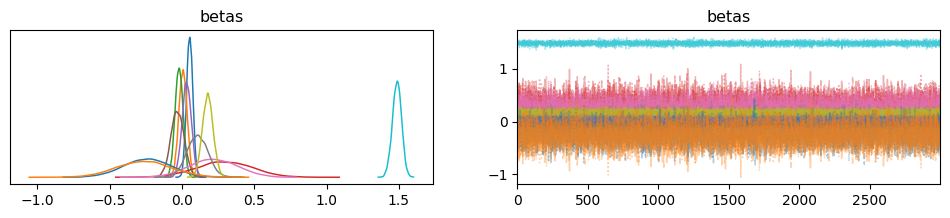

In [342]:
# Fit the model to get beta estimates
trace_gk = fit_dirichlet_regression(X_gk, gk_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_gk = trace_gk.posterior['betas'].mean(axis=(0,1)).values

# trace_gk
az.plot_trace(trace_gk, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_gk, var_names=["betas"], round_to=2)
summary

Fitting Dirichlet regression model with PyMC...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 512 seconds.


✅ Model fitting complete.


array([[<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>]], dtype=object)

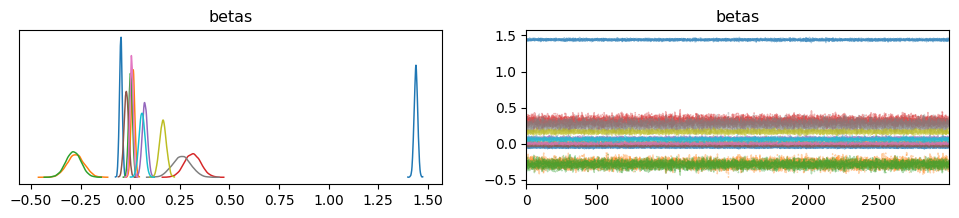

In [305]:
# Fit the model to get beta estimates
trace_def = fit_dirichlet_regression(X_def, def_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_def = trace_def.posterior['betas'].mean(axis=(0,1)).values

trace_def
az.plot_trace(trace_def, combined=True)

Fitting Dirichlet regression model with PyMC...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 646 seconds.


✅ Model fitting complete.


array([[<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>]], dtype=object)

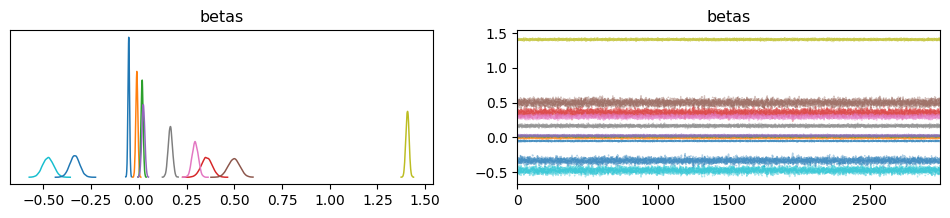

In [313]:
# Fit the model to get beta estimates
trace_mid = fit_dirichlet_regression(X_mid, mid_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_mid = trace_mid.posterior['betas'].mean(axis=(0,1)).values

trace_mid
az.plot_trace(trace_mid, combined=True)

In [315]:
# Fit the model to get beta estimates
trace_fwd = fit_dirichlet_regression(X_fwd, fwd_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_fwd = trace_fwd.posterior['betas'].mean(axis=(0,1)).values

trace_fwd
az.plot_trace(trace_fwd, combined=True)

Fitting Dirichlet regression model with PyMC...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas]


KeyboardInterrupt: 

In [314]:
joblib.dump(trace_gk, './trace_gk')
joblib.dump(trace_def, './trace_def')
joblib.dump(trace_mid, './trace_mid')
joblib.dump(trace_fwd, './trace_fwd')

['./trace_fwd']

In [132]:
beta_estimates_fwd

array([ 0.2048114 ,  0.02744858,  0.10912305,  0.13259471,  0.24606473,
        0.12022504, -0.00706065, -0.10280684])

In [ ]:
 # Convert to pandas DataFrame
pd.DataFrame({
    "gk": beta_estimates_gk
}).to_csv('./gk_beta_1.csv', index=False)

pd.DataFrame({
    "def": beta_estimates_def
}).to_csv('./def_beta_1.csv', index=False)

pd.DataFrame({
    "mid": beta_estimates_mid
}).to_csv('./mid_beta_1.csv', index=False)

pd.DataFrame({
    "fwd": beta_estimates_fwd
}).to_csv('./fwd_beta_1.csv', index=False)

## Use betas


## Simulate selection probs


In [62]:
def simulate_observed_probs(X: pd.DataFrame):
    X = X.fillna(0)
    np.random.seed(42)
    num_features = X.shape[1]
    true_beta = np.random.uniform(-0.5, 0.5, size=(num_features,))
    logits = X @ true_beta
    probs = np.exp(logits)
    probs /= probs.sum()
    return probs

# simulate_observed_probs(X_gk_pca)

### Get betas


In [ ]:
def dirichlet_regression_beta_auto(data, observed_probs):
    """
    Perform Bayesian Dirichlet Regression.
    If no observed_probs are given, simulate them based on features.
    """
    if not isinstance(data, pd.DataFrame):
        raise ValueError("Data must be a pandas DataFrame.")

    if data.isnull().any().any():
        raise ValueError("Data contains NaN values. Please clean it first.")

    num_players, num_features = data.shape
    print(f"Number of Players: {num_players}, Number of Features: {num_features}")

    X = data.to_numpy(dtype=np.float64)

    if observed_probs is None:
        observed_probs = simulate_observed_probs(data)
        print("Simulated observed probabilities:", observed_probs)


    with pm.Model() as model:
        # Wide normal prior
        beta = pm.Normal("beta", mu=0, sigma=10, shape=(num_features,))

        eta = pm.math.dot(X, beta)
        alpha = pm.math.exp(eta)

        pm.Dirichlet("obs", a=alpha, observed=observed_probs)

        trace = pm.sample(
            draws=10000,
            # tune=50,
            target_accept=0.95,
            chains=4,
            cores=2,
            return_inferencedata=True,
            progressbar=True,
            # nuts_sampler="numpyro"

        )

    beta_estimated = trace.posterior["beta"].mean(dim=["chain", "draw"]).values

    print("Estimated β values:\n", beta_estimated)
    return beta_estimated, trace

In [ ]:
# Suppose your player data
X_data_gk = X_gk_pca.copy()

# Now fit!
beta_gk, trace_gk = dirichlet_regression_beta_auto(X_gk, gk_probs)
joblib.dump(beta_gk, './beta_gk_')


Number of Players: 440, Number of Features: 36


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 267 seconds.


Estimated β values:
 [-0.05075763  0.16025228  0.01033355 -0.02838126  0.03516302  0.00948877
  0.05527611 -0.02403558  0.17481191 -0.08508893  0.1149977   0.17734667
 -0.28483685 -0.07054916 -0.00199312 -0.04067058  0.21532261  0.06787077
 -0.17575148 -0.11193719 -0.04792933  0.14787747 -0.09074349 -0.04678278
 -0.17218858  0.01388744 -0.19662298 -0.02995233 -0.17254208 -0.11779406
  0.17687521  0.02753878 -0.13697038  0.01704889  0.03151004  0.02830961]


['./beta_gk_']

array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

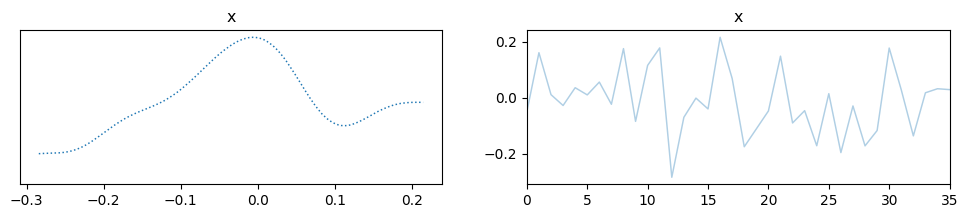

In [77]:
az.plot_trace(beta_gk, combined=True)


In [79]:
trace_gk

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [67]:
# Suppose your player data
X_data_def = X_def_pca.copy()

# Now fit!
beta_def = dirichlet_regression_beta_auto(X_data_def, def_probs)

Number of Players: 2122, Number of Features: 43
Simulated observed probabilities: 1       1.000000e-09
2       1.000000e-09
3       1.000000e-09
4       7.094519e-05
5       3.807875e-04
            ...     
7531    1.000000e-09
7532    1.000000e-09
7533    1.000000e-09
7534    1.000000e-09
7535    1.000000e-09
Name: ownership_percent, Length: 2122, dtype: float64


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 645 seconds.


Estimated β values:
 [ 0.10935805 -0.06600547  0.05712326 -0.08539319  0.03985844  0.04079411
 -0.00929997  0.02051653  0.10931137 -0.01269434  0.00836984 -0.00448197
  0.01234197  0.01866711  0.16118843  0.11289324  0.07776959  0.03458661
  0.06416056  0.03453213  0.00668548  0.08325686  0.01216366  0.03347986
 -0.01599589 -0.10067694  0.02811443 -0.05728412 -0.06592892 -0.06673129
  0.04035594  0.12583511  0.01413245 -0.05558944  0.0059794  -0.06838795
 -0.07243846 -0.17336559 -0.11349632 -0.23461379  0.08539944  0.0758072
 -0.01025085]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

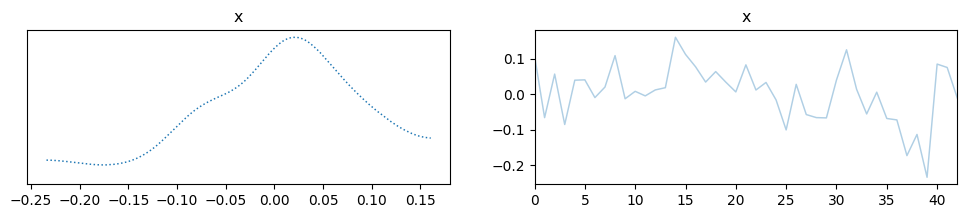

In [68]:
az.plot_trace(beta_def, combined=True)

In [69]:
# Suppose your player data
X_data_mid = X_mid_pca.copy()

# Now fit!
beta_mid = dirichlet_regression_beta_auto(X_data_mid, mid_probs)

Number of Players: 2898, Number of Features: 41
Simulated observed probabilities: 49      1.000000e-09
50      3.423068e-05
51      1.000000e-09
52      1.000000e-09
53      3.957922e-05
            ...     
7622    1.000000e-09
7623    1.000000e-09
7624    1.000000e-09
7625    1.000000e-09
7626    8.664640e-05
Name: ownership_percent, Length: 2898, dtype: float64


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 779 seconds.


Estimated β values:
 [ 0.11563396  0.02197309  0.01576621 -0.06135816  0.03941934 -0.02274065
 -0.04350963  0.09519809  0.05192299  0.00612984  0.04803557  0.06219474
  0.00495943  0.05379317  0.00415769  0.1475381   0.00734413  0.06039934
  0.02761249 -0.03159965 -0.07056228 -0.12374027 -0.04472006 -0.00312563
 -0.0123722  -0.06443853  0.02450881 -0.05250381  0.03068622  0.04457324
 -0.0230198  -0.08991976  0.01728646 -0.02630212  0.11669523 -0.10842136
 -0.13133619  0.00907391 -0.16828804 -0.15537998 -0.0609233 ]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

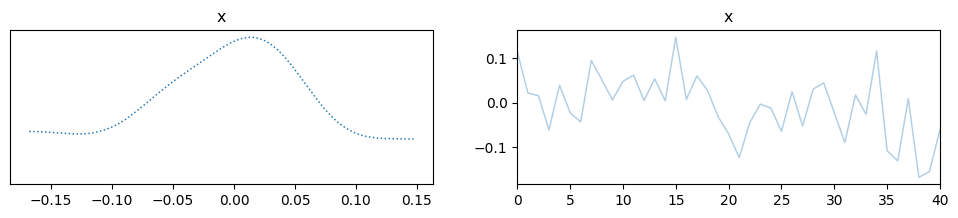

In [70]:
az.plot_trace(beta_mid, combined=True)

In [71]:
# Suppose your player data
X_data_fwd = X_fwd_pca.copy()
X_data_fwd = X_data_fwd.fillna(0)

# Now fit!
beta_fwd = dirichlet_regression_beta_auto(X_data_fwd, fwd_probs)


Number of Players: 959, Number of Features: 40
Simulated observed probabilities: 202     1.000000e-09
203     1.000000e-09
204     1.000000e-09
205     1.000000e-09
206     1.000000e-09
            ...     
7656    1.000000e-09
7657    1.000000e-09
7658    1.000000e-09
7659    1.000000e-09
7660    1.000000e-09
Name: ownership_percent, Length: 959, dtype: float64


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 359 seconds.


Estimated β values:
 [ 0.11725663  0.00454768  0.02815001  0.08194274  0.00064359  0.12346971
  0.02909898 -0.02726569 -0.01023559 -0.03933527 -0.0018487  -0.00050357
 -0.02846513 -0.03771949 -0.06665958  0.11386885 -0.04073227  0.09260474
 -0.00693881  0.0758423   0.08131965  0.00550131  0.1200668   0.17673515
 -0.06206928 -0.09934789 -0.12273107 -0.10348093  0.103852    0.00113419
  0.08685037 -0.12920219 -0.10714665  0.08883595 -0.00333795  0.10131501
  0.19557866  0.12068775 -0.12789109 -0.01792869]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

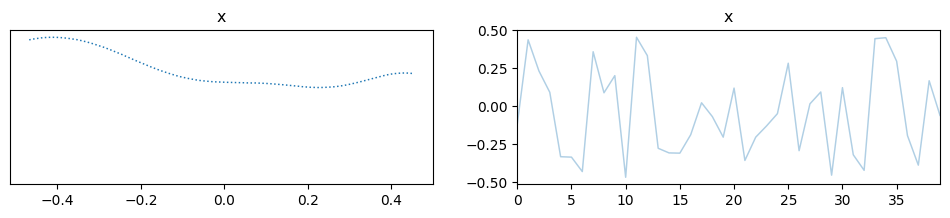

In [ ]:
az.plot_trace(beta_fwd, combined=True)

In [ ]:
 # Convert to pandas DataFrame
pd.DataFrame({
    "gk": beta_gk
}).to_csv('./gk_beta.csv', index=False)

pd.DataFrame({
    "def": beta_def
}).to_csv('./def_beta.csv', index=False)

pd.DataFrame({
    "mid": beta_mid
}).to_csv('./mid_beta.csv', index=False)

pd.DataFrame({
    "fwd": beta_fwd
}).to_csv('./fwd_beta.csv', index=False)